<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase;
   ">
        Usina de Energia<br>Multicolinearidade e Homocedasticidade
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
   ">
   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: 0.9rem;
        color: #94a3b8;
   ">
       <span style="font-weight: 500;">
            Por: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong> - Cientista de Dados
       </span>
       <div style="display: flex; gap: 20px; font-weight: 500;">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos" 
               target="_blank" 
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com" 
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova" 
               target="_blank" 
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>

</div>

## Introdução

Neste projeto, aplico os conceitos de multicolinearidade e homocedasticidade em dados de uma usina de energia. O objetivo é construir um modelo de regressão linear para prever a potência elétrica gerada (`PE`), diagnosticar a presença de multicolinearidade com o VIF, tomar medidas corretivas quando necessário, e avaliar o comportamento dos resíduos para verificar homocedasticidade.

**Seções deste notebook:**

1. Carregando e conhecendo os dados
2. Análise de correlação
3. Separando em treino e teste
4. Modelo completo e diagnóstico de multicolinearidade
5. Modelo reduzido: removendo a multicolinearidade
6. Comparando os modelos
7. Análise de resíduos e homocedasticidade
8. Conclusão e Considerações Finais
9. Referências

---

## 1. Carregando e conhecendo os dados

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import session_info

print('- BIBLIOTECAS CARREGADAS -')
session_info.show()

- BIBLIOTECAS CARREGADAS -


In [6]:
try:
    dados = pd.read_csv("usina.csv")
    print(' - DADOS CARREGADOS -')

except FileNotFoundError:
    print("Arquivo não encontrado, verifique o caminho")
except Exception as e:
    print(f'Erro: {str(e)}')

 - DADOS CARREGADOS -


In [7]:
dados.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [8]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [9]:
dados.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


O dataset contém 9.568 registros sem valores ausentes. A tabela abaixo descreve cada variável:

| Variável | Tipo | Descrição |
|---|---|---|
| `AT` | float | Temperatura ambiente em °C |
| `V` | float | Velocidade de exaustão em cm/s |
| `AP` | float | Pressão ambiente em milibar |
| `RH` | float | Umidade relativa em % |
| `PE` | float | Potência elétrica gerada em MW (variável alvo) |

---

## 2. Análise de correlação

In [10]:
corr = dados.corr()
corr['PE'].sort_values(ascending=False)
corr

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


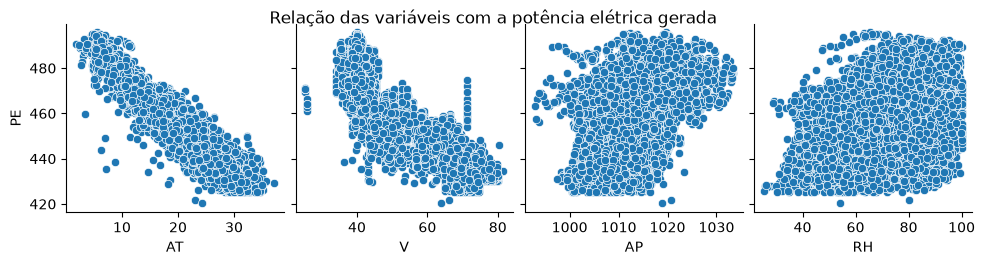

In [11]:
sns.pairplot(dados, y_vars='PE', x_vars=['AT', 'V', 'AP', 'RH'])
plt.suptitle('Relação das variáveis com a potência elétrica gerada', y=1.02)
plt.show()

As variáveis `AT` e `V` têm correlação negativa forte com `PE` (-0,95 e -0,87, respectivamente): quanto maior a temperatura e a velocidade de exaustão, menor a potência gerada. `AP` e `RH` têm correlação positiva moderada (0,52 e 0,39). A correlação elevada entre `AT` e `V` entre si (0,84) já antecipa um possível problema de multicolinearidade, que verificamos com o VIF na seção 4.

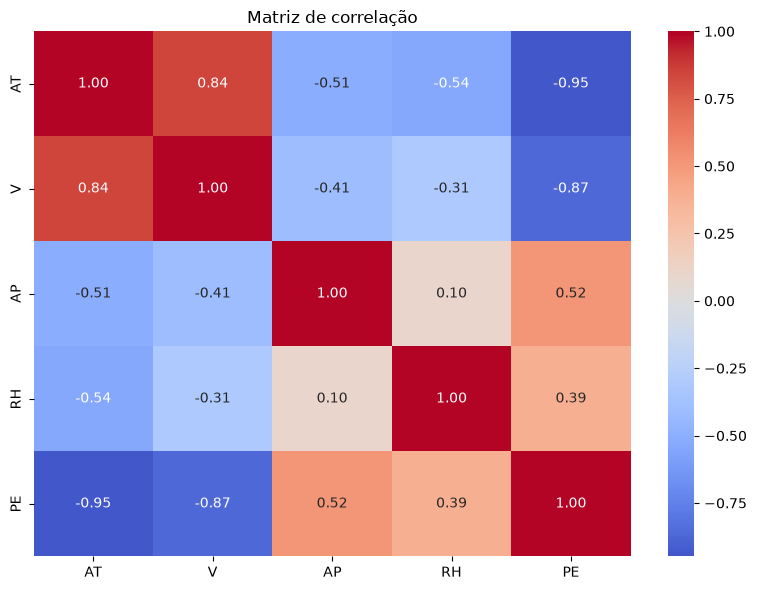

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlação')
plt.tight_layout()
plt.show()

---

## 3. Separando em treino e teste

In [13]:
y = dados['PE']
X = dados.drop(columns='PE')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=230)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste:  {X_test.shape[0]} registros")

Treino: 6697 registros
Teste:  2871 registros


In [14]:
X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)

---

## 4. Modelo completo e diagnóstico de multicolinearidade

Ajusto o modelo com todas as variáveis disponíveis e calculo o VIF para cada preditor.

In [15]:
cols_full = ['const', 'AT', 'V', 'AP', 'RH']

modelo_completo = sm.OLS(y_train, X_train_c[cols_full]).fit()
print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:02:19   Log-Likelihood:                -19662.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.937e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        446.1042     11.769     37.905      0.0

In [16]:
vif_full = pd.DataFrame()
vif_full['variavel'] = cols_full
vif_full['vif'] = [variance_inflation_factor(X_train_c[cols_full].values, i)
                   for i in range(len(cols_full))]
print(vif_full)

  variavel           vif
0    const  44603.788615
1       AT      6.034363
2        V      3.954998
3       AP      1.468530
4       RH      1.717508


O VIF de `AT` é **6,03**, acima do limiar de 5 que sinaliza multicolinearidade relevante. A raiz do problema está na alta correlação entre `AT` e `V` (0,84): as duas variáveis descrevem fenômenos físicos relacionados, pois o aumento de temperatura tende a elevar também a velocidade de exaustão. Quando duas variáveis carregam informação parcialmente redundante, o modelo tem dificuldade em isolar o efeito individual de cada uma, inflando a variância dos coeficientes.

A medida mais direta para resolver isso é remover a variável com maior VIF. Entre `AT` (VIF = 6,03) e `V` (VIF = 3,95), removo `V`, pois `AT` tem correlação individual mais forte com `PE` (-0,95 contra -0,87) e, portanto, maior capacidade explicativa.

---

## 5. Modelo reduzido: removendo a multicolinearidade

In [17]:
cols_red = ['const', 'AT', 'AP', 'RH']

modelo_reduzido = sm.OLS(y_train, X_train_c[cols_red]).fit()
print(modelo_reduzido.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                 2.599e+04
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:04:55   Log-Likelihood:                -20025.
No. Observations:                6697   AIC:                         4.006e+04
Df Residuals:                    6693   BIC:                         4.008e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        483.5395     12.341     39.183      0.0

In [18]:
vif_red = pd.DataFrame()
vif_red['variavel'] = cols_red
vif_red['vif'] = [variance_inflation_factor(X_train_c[cols_red].values, i)
                  for i in range(len(cols_red))]
print(vif_red)

  variavel           vif
0    const  44014.355564
1       AT      2.025850
2       AP      1.446885
3       RH      1.505641


Com a remoção de `V`, o VIF de `AT` cai de 6,03 para **2,03** e os demais preditores ficam entre 1,45 e 1,51. O modelo reduzido está livre de multicolinearidade relevante. A equação resultante é:

> **PE = 483,54 - 2,374 × AT + 0,032 × AP - 0,202 × RH**

Todos os coeficientes são estatisticamente significativos (p < 0,001). A cada grau celsius de aumento na temperatura, a potência gerada reduz em média 2,37 MW - o efeito de maior magnitude no modelo.

---

## 6. Comparando os modelos

In [19]:
pred_full = modelo_completo.predict(X_test_c[cols_full])
pred_red  = modelo_reduzido.predict(X_test_c[cols_red])

print("R² (treino):")
print(f"  Modelo completo (4 vars):  {modelo_completo.rsquared:.4f}")
print(f"  Modelo reduzido (3 vars):  {modelo_reduzido.rsquared:.4f}")

print("\nR² (teste):")
print(f"  Modelo completo:           {r2_score(y_test, pred_full):.4f}")
print(f"  Modelo reduzido:           {r2_score(y_test, pred_red):.4f}")

R² (treino):
  Modelo completo (4 vars):  0.9291
  Modelo reduzido (3 vars):  0.9209

R² (teste):
  Modelo completo:           0.9278
  Modelo reduzido:           0.9211


| Modelo | Variáveis | R² treino | R² teste |
|--------|-----------|-----------|----------|
| Modelo completo | `AT`, `V`, `AP`, `RH` | 0,9291 | 0,9278 |
| Modelo reduzido | `AT`, `AP`, `RH` | 0,9209 | 0,9211 |

A remoção de `V` reduz o R² de treino em apenas 0,008. No conjunto de teste, a diferença é ainda menor. O modelo reduzido troca uma pequena parcela de poder explicativo pela eliminação da multicolinearidade, tornando os coeficientes mais estáveis e interpretáveis.

---

## 7. Análise de resíduos e homocedasticidade

In [20]:
y_prev_train = modelo_reduzido.predict(X_train_c[cols_red])
residuos = modelo_reduzido.resid
residuos

3522    16.202356
4271    -7.510989
6811     4.945503
1801    -3.377411
8036     0.841199
          ...    
1879    -1.179588
7364     3.637071
5363     4.500702
4873    -3.772452
6867     2.022509
Length: 6697, dtype: float64

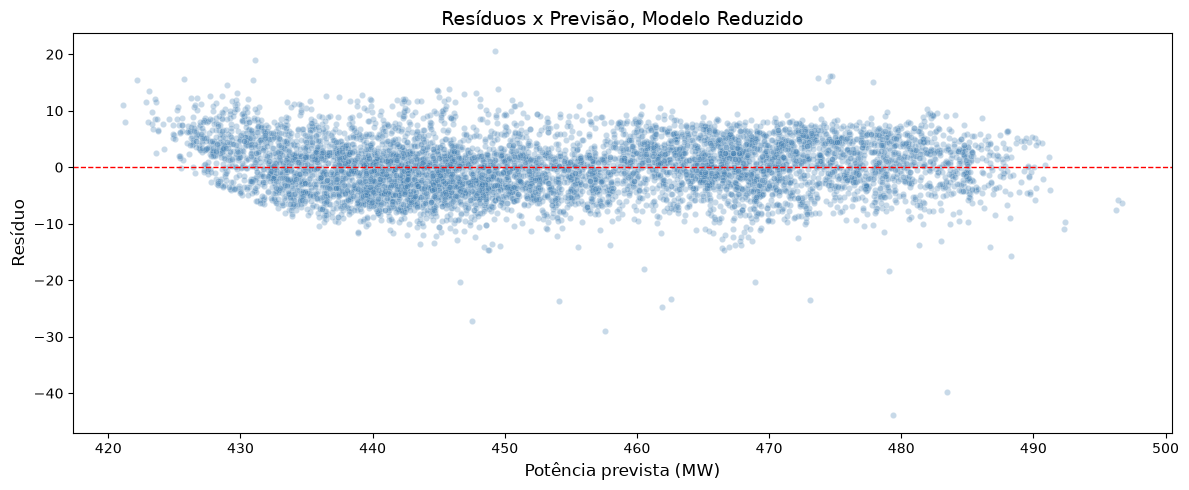

In [21]:
ax = sns.scatterplot(x=y_prev_train, y=residuos, s=20, alpha=0.3, color='steelblue')
ax.figure.set_size_inches(12, 5)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Resíduos x Previsão, Modelo Reduzido', fontsize=14)
ax.set_xlabel('Potência prevista (MW)', fontsize=12)
ax.set_ylabel('Resíduo', fontsize=12)
plt.tight_layout()
plt.show()

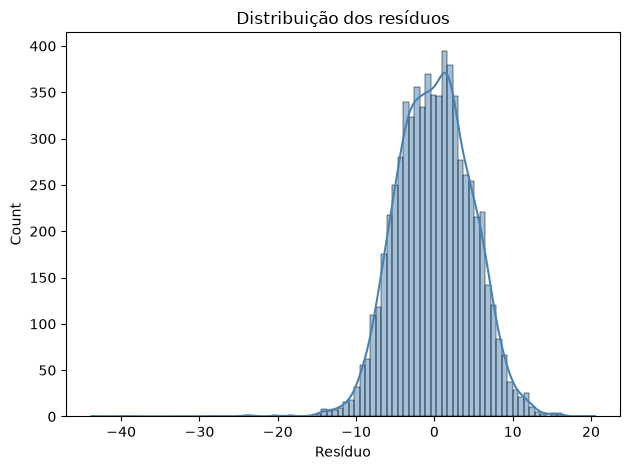

In [22]:
sns.histplot(residuos, kde=True, color='steelblue')
plt.title('Distribuição dos resíduos')
plt.xlabel('Resíduo')
plt.tight_layout()
plt.show()

O gráfico de dispersão dos resíduos mostra uma nuvem de pontos distribuída de forma aleatória ao redor da linha zero, sem padrão de funil, curvatura ou estrutura sistemática. Isso indica **homocedasticidade**: a variância dos erros é aproximadamente constante ao longo de toda a faixa de valores previstos. O histograma confirma uma distribuição dos resíduos próxima da normal, simétrica em torno de zero.

O modelo reduzido atende às premissas da regressão linear ordinária tanto em termos de multicolinearidade quanto de comportamento dos resíduos.

---

## 8. Conclusão

### Síntese dos resultados

| Métrica | Valor |
|---|---|
| Observações no dataset | 9.568 |
| Proporção treino / teste | 70% / 30% |
| VIF máximo, modelo completo | 6,03 (`AT`) |
| VIF máximo, modelo reduzido | 2,03 (`AT`) |
| R² modelo completo (teste) | 0,9278 |
| R² modelo reduzido (teste) | **0,9211** |
| Comportamento dos resíduos | Homocedástico |

### Considerações

O modelo completo apresenta VIF de 6,03 para `AT`, acima do limiar de 5, motivado pela alta correlação entre `AT` e `V` (0,84). A remoção de `V` resolve o problema: o VIF de `AT` cai para 2,03 e o desempenho preditivo se mantém em R² = 0,92 no conjunto de teste. A análise de resíduos confirma homocedasticidade, com erros distribuídos de forma aleatória ao redor de zero sem padrão sistemático. `AT` é o preditor de maior impacto: cada grau celsius adicional reduz a potência gerada em 2,37 MW em média.

### Limitações

O dataset não inclui informações sobre o tipo de turbina, combustível utilizado ou condições de manutenção, variáveis que podem ter efeito relevante sobre a potência gerada. A remoção de `V` resolve a multicolinearidade mas descarta informação real: em um contexto de produção, uma abordagem alternativa seria combinar `AT` e `V` em um único índice composto ou aplicar PCA para reter a variância de ambas sem redundância.

---

## 9. Referências

- Alura. **Data Science: testando relações com Regressão Linear**. Disponível em: [https://www.alura.com.br/curso-online-data-science-testando-relacoes-regressao-linear](https://www.alura.com.br/curso-online-data-science-testando-relacoes-regressao-linear). Acesso em: jun. 2026.

- UCI Machine Learning Repository. **Combined Cycle Power Plant Dataset**. Disponível em: [https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant). Acesso em: jun. 2026.

- Statsmodels. **Regression and Linear Models**. Disponível em: [https://www.statsmodels.org/stable/regression.html](https://www.statsmodels.org/stable/regression.html). Acesso em: jun. 2026.

- Scikit-learn. **sklearn.model_selection.train_test_split**. Disponível em: [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Acesso em: jun. 2026.

- ESALQ/USP. **Análise de Regressão**. Disponível em: [https://www.esalq.usp.br/biblioteca/sites/default/files/Analise_Regressão.pdf](https://www.esalq.usp.br/biblioteca/sites/default/files/Analise_Regressão.pdf). Acesso em: jun. 2026.